In [10]:
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import roc_curve, auc

In [11]:
data = load_breast_cancer()
X = data.data
y = data.target
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

In [12]:
lr_model = LogisticRegression(max_iter=10000)
lr_model.fit(X_train, y_train)
lr_y_pred_proba = lr_model.predict_proba(X_test)[:, 1]
dt_model = DecisionTreeClassifier()
dt_model.fit(X_train, y_train)
dt_y_pred_proba = dt_model.predict_proba(X_test)[:, 1]

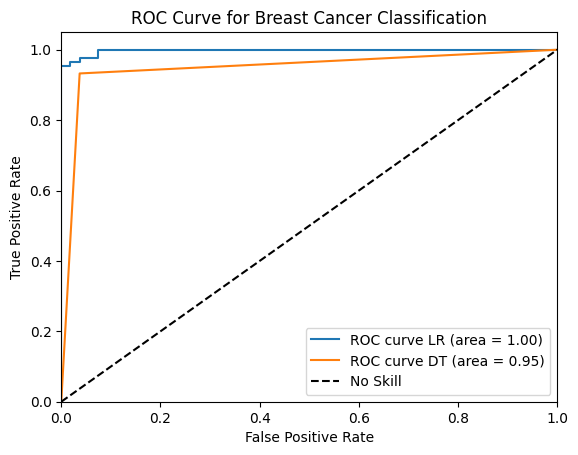

In [13]:
# Calculate ROC curve
lr_fpr, lr_tpr, thresholds = roc_curve(y_test, lr_y_pred_proba)
lr_roc_auc = auc(lr_fpr, lr_tpr)

dt_fpr, dt_tpr, thresholds = roc_curve(y_test, dt_y_pred_proba)
dt_roc_auc = auc(dt_fpr, dt_tpr)

# Plot the ROC curve
plt.figure()
plt.plot(lr_fpr, lr_tpr, label='ROC curve LR (area = %0.2f)' % lr_roc_auc)
plt.plot(dt_fpr, dt_tpr, label='ROC curve DT (area = %0.2f)' % dt_roc_auc)
plt.plot([0, 1], [0, 1], 'k--', label='No Skill')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve for Breast Cancer Classification')
plt.legend()
plt.show()